# Sinkhorn potentials along the iteration

This notebook generates `fig:sinkhorn-potentials-iterations`.  It uses the same one-dimensional histograms and KL-normalized potential convention as `fig:sinkhorn-dual-potentials-epsilon`, but fixes `epsilon` and follows the alternating row/column scalings through selected iterations.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from scipy.special import logsumexp
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_rgb
from matplotlib.patches import Polygon

from figure_style import (
    BLUE,
    DIRAC_MARKER_SIZE,
    GRAY,
    LIGHT_GRAY,
    ORANGE,
    RED,
    VIOLET,
    box_axes,
    canonical_matching_clouds,
    figure_dir,
    interp_color,
    padded_limits,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()
np.random.seed(0)

def normal_pdf(x, mean, std):
    return np.exp(-0.5 * ((x - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def mixture_pdf(x, weights, means, stds):
    density = np.zeros_like(x, dtype=float)
    for weight, mean, std in zip(weights, means, stds):
        density += weight * normal_pdf(x, mean, std)
    return density


def sinkhorn_histograms(n=170):
    grid = np.linspace(-3.25, 3.15, n)
    alpha_density = mixture_pdf(grid, [0.58, 0.42], [-1.95, -0.10], [0.34, 0.54])
    beta_density = mixture_pdf(grid, [0.42, 0.58], [-0.75, 1.55], [0.42, 0.36])
    a = alpha_density / alpha_density.sum()
    b = beta_density / beta_density.sum()
    C = (grid[:, None] - grid[None, :]) ** 2
    C = C / np.median(C[C > 0])
    return grid, alpha_density, beta_density, a, b, C


def _gauge_potentials(a, f, g):
    shift = float(np.dot(a, f))
    return f - shift, g + shift


def kl_normalized_solution(a, b, C, epsilon, *, num_iter=40000, stop_thr=1e-13):
    """Log-domain Sinkhorn scaling for the KL reference a \\otimes b.

    The scalings u,v are defined by
        P_ij = u_i a_i b_j exp(-C_ij/epsilon) v_j,
    so f=epsilon log u and g=epsilon log v are the KL-normalized dual
    potentials.  This is not POT's default entropy convention, hence the
    explicit log-sum-exp updates.
    """
    log_a = np.log(np.maximum(a, 1e-300))
    log_b = np.log(np.maximum(b, 1e-300))
    log_kernel = -C / epsilon
    log_u = np.zeros_like(a)
    log_v = np.zeros_like(b)
    for it in range(num_iter):
        old_log_u = log_u.copy()
        log_u = -logsumexp(log_b[None, :] + log_kernel + log_v[None, :], axis=1)
        log_v = -logsumexp(log_a[:, None] + log_kernel + log_u[:, None], axis=0)
        if it % 10 == 0 and epsilon * np.max(np.abs(log_u - old_log_u)) < stop_thr:
            break
    log_plan = log_a[:, None] + log_b[None, :] + log_kernel + log_u[:, None] + log_v[None, :]
    row_error = np.max(np.abs(np.exp(logsumexp(log_plan, axis=1)) - a))
    col_error = np.max(np.abs(np.exp(logsumexp(log_plan, axis=0)) - b))
    if max(row_error, col_error) > 2e-10:
        raise RuntimeError(f"Sinkhorn marginals not accurate enough: {row_error:.2e}, {col_error:.2e}")
    f, g = _gauge_potentials(a, epsilon * log_u, epsilon * log_v)
    plan = np.exp(np.clip(log_plan, -745.0, 80.0))
    return plan, f, g


def _cdf_from_density(grid, density):
    increments = 0.5 * (density[:-1] + density[1:]) * np.diff(grid)
    cdf = np.r_[0.0, np.cumsum(increments)]
    return np.maximum.accumulate(cdf / cdf[-1])


def _cumulative_trapezoid(grid, values):
    increments = 0.5 * (values[:-1] + values[1:]) * np.diff(grid)
    return np.r_[0.0, np.cumsum(increments)]


def hard_dual_from_quantiles(grid, alpha_density, beta_density, a, C):
    """Unregularized one-dimensional quadratic dual for the same grid and gauge."""
    alpha_density = alpha_density / np.trapezoid(alpha_density, grid)
    beta_density = beta_density / np.trapezoid(beta_density, grid)
    Fa = _cdf_from_density(grid, alpha_density)
    Fb = _cdf_from_density(grid, beta_density)
    T = np.interp(np.clip(Fa, 1e-5, 1.0 - 1e-5), Fb, grid)
    cost_scale = np.median(((grid[:, None] - grid[None, :]) ** 2)[C > 0])
    f_prime = 2.0 * (grid - T) / cost_scale
    f = _cumulative_trapezoid(grid, f_prime)
    g = np.min(C - f[:, None], axis=0)
    return _gauge_potentials(a, f, g)


## Iterative logarithmic scalings

At iteration `k`, the current coupling has the form `diag(u) K diag(v)`, where `K=(a otimes b) exp(-C/epsilon)`.  The plotted potentials are `epsilon log u` and `epsilon log v`, with the same gauge in every panel.

In [2]:
fig_name = "sinkhorn-potentials-iterations"
out = figure_dir(fig_name)

grid, alpha_density, beta_density, a, b, C = sinkhorn_histograms(n=170)
epsilon = 0.045
log_a = np.log(np.maximum(a, 1e-300))
log_b = np.log(np.maximum(b, 1e-300))
log_kernel = -C / epsilon
selected = [0, 1, 3, 12]

log_u = np.zeros_like(a)
log_v = np.zeros_like(b)
states = {}
for k in range(max(selected) + 1):
    f, g = _gauge_potentials(a, epsilon * log_u, epsilon * log_v)
    if k in selected:
        states[k] = (f.copy(), g.copy())
    log_u = -logsumexp(log_b[None, :] + log_kernel + log_v[None, :], axis=1)
    log_v = -logsumexp(log_a[:, None] + log_kernel + log_u[:, None], axis=0)

# Separate QA check: a fully converged solve uses the same KL convention.
_ = kl_normalized_solution(a, b, C, epsilon)

all_values = np.concatenate([np.r_[f, g] for f, g in states.values()])
ymin, ymax = np.percentile(all_values, [1, 99])
pad = 0.16 * (ymax - ymin)
ymin, ymax = ymin - pad, ymax + pad
density_base = ymin + 0.055 * (ymax - ymin)
density_height = 0.145 * (ymax - ymin)

## Exported iteration panels

All panels share the same axes.  The faint silhouettes provide spatial context for the red source and blue target histograms.

In [3]:
def draw_state(k, filename):
    f, g = states[k]
    fig, ax = plt.subplots(figsize=(2.36, 1.84))
    alpha_sil = density_base + density_height * alpha_density / alpha_density.max()
    beta_sil = density_base + density_height * beta_density / beta_density.max()
    ax.fill_between(grid, density_base, alpha_sil, color=RED, alpha=0.15, linewidth=0, zorder=1)
    ax.fill_between(grid, density_base, beta_sil, color=BLUE, alpha=0.15, linewidth=0, zorder=1)
    ax.plot(grid, alpha_sil, color=RED, lw=0.55, alpha=0.75, zorder=2)
    ax.plot(grid, beta_sil, color=BLUE, lw=0.55, alpha=0.75, zorder=2)
    ax.plot(grid, f, color=RED, lw=1.14, zorder=3)
    ax.plot(grid, g, color=BLUE, lw=1.14, zorder=3)
    ax.set_xlim(grid.min(), grid.max())
    ax.set_ylim(ymin, ymax)
    ax.set_xticks([])
    ax.set_yticks([])
    box_axes(ax)
    save_pdf(fig, out / filename, pad_inches=0.055)
    plt.close(fig)


for k in selected:
    draw_state(k, f"iter-{k}.pdf")

## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


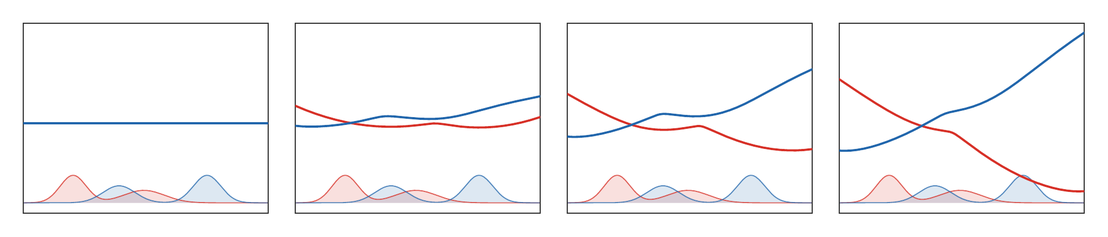

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/sinkhorn-potentials-iterations.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/sinkhorn-potentials-iterations.png")
display(Image(filename=str(_thumb)))
